**Instalación** **de**  **dependencias**

In [8]:
!pip install -q apache-airflow pandera sqlalchemy pandas matplotlib seaborn

Directorio del proyecto y los paquetes src y dags

In [10]:
import os

# Crear estructura de carpetas locales en Colab
os.makedirs("src", exist_ok=True)
os.makedirs("dags", exist_ok=True)
os.makedirs("data", exist_ok=True)

print(" Carpetas 'src', 'dags' y 'data' creadas correctamente.")

 Carpetas 'src', 'dags' y 'data' creadas correctamente.


In [12]:
!pip install -q kagglehub

import kagglehub
import os
import shutil

# Asegurar que exista la carpeta data/
os.makedirs("data", exist_ok=True)

# 1. Descargar Grammy Awards Dataset desde Kaggle
print("Descargando Grammy Awards dataset...")
grammy_path = kagglehub.dataset_download("unanimad/grammy-awards")
for file in os.listdir(grammy_path):
    if file.endswith(".csv"):
        shutil.copy(os.path.join(grammy_path, file), "data/grammys_raw.csv")
        print(" -> Guardado como data/grammys_raw.csv")

# 2. Descargar Spotify Tracks Dataset desde Kaggle
print("\nDescargando Spotify Tracks dataset...")
spotify_path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
for file in os.listdir(spotify_path):
    if file.endswith(".csv"):
        shutil.copy(os.path.join(spotify_path, file), "data/spotify_tracks.csv")
        print(" -> Guardado como data/spotify_tracks.csv")

# Verificar archivos guardados
print("\n Archivos listos en la carpeta data/:", os.listdir("data"))

Descargando Grammy Awards dataset...
Using Colab cache for faster access to the 'grammy-awards' dataset.
 -> Guardado como data/grammys_raw.csv

Descargando Spotify Tracks dataset...
Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
 -> Guardado como data/spotify_tracks.csv

 Archivos listos en la carpeta data/: ['spotify_tracks.csv', 'grammys_raw.csv']


Módulo de BD e Inicialización

In [13]:
%%writefile src/database.py
from sqlalchemy import create_engine
import pandas as pd

DB_PATH = 'sqlite:///data/etl_workshop.db'

def get_engine():
    return create_engine(DB_PATH)

def init_db_grammys(csv_path='data/grammys_raw.csv'):
    """Carga inicial del CSV de Grammys a la Base de Datos antes del orquestador"""
    engine = get_engine()
    df_grammys = pd.read_csv(csv_path)
    df_grammys.to_sql('grammys_raw', con=engine, if_exists='replace', index=False)
    print("Tabla 'grammys_raw' cargada exitosamente en la BD SQL.")

Writing src/database.py


Módulo de Calidad de Datos con Pandera

In [14]:
%%writefile src/quality.py
import pandera as pa

spotify_schema = pa.DataFrameSchema({
    "track_id": pa.Column(str, nullable=False),
    "artists": pa.Column(str, nullable=False),
    "album_name": pa.Column(str, nullable=True),
    "track_name": pa.Column(str, nullable=False),
    "popularity": pa.Column(int, pa.Check.in_range(0, 100), nullable=True),
    "duration_ms": pa.Column(int, pa.Check.greater_than(0), nullable=True)
})

def validate_spotify_data(df):
    try:
        validated_df = spotify_schema.validate(df)
        print(" Validaciones de calidad de Pandera superadas correctamente.")
        return validated_df
    except pa.errors.SchemaError as e:
        print(f" Error en la validación de calidad: {e}")
        raise e

Overwriting src/quality.py


Transformación y Merge.
Normaliza cadenas de texto para hacer el cruce entre Spotify y Grammys.

In [15]:
%%writefile src/transform.py
import pandas as pd

def transform_spotify(df_spotify):
    df_spotify['artist_clean'] = df_spotify['artists'].astype(str).str.lower().str.strip()
    df_spotify['track_clean'] = df_spotify['track_name'].astype(str).str.lower().str.strip()
    return df_spotify

def transform_grammys(df_grammys):
    # En el dataset real de Kaggle, el artista suele estar en 'artist' o 'worker'
    artist_col = 'artist' if 'artist' in df_grammys.columns else 'worker'
    nominee_col = 'nominee' if 'nominee' in df_grammys.columns else 'title'

    df_grammys['artist_clean'] = df_grammys[artist_col].astype(str).str.lower().str.strip()
    df_grammys['track_clean'] = df_grammys[nominee_col].astype(str).str.lower().str.strip()
    return df_grammys

def merge_datasets(df_spotify, df_grammys):
    merged_df = pd.merge(
        df_spotify,
        df_grammys,
        on=['artist_clean'],
        how='inner',
        suffixes=('_spotify', '_grammy')
    )
    return merged_df

Writing src/transform.py


Carga y Guarda el resultado consolidado en la BD e imprime el CSV exportado.

In [16]:
%%writefile src/load.py
from src.database import get_engine

def save_to_db(df, table_name='spotify_grammys_merged'):
    engine = get_engine()
    df.to_sql(table_name, con=engine, if_exists='replace', index=False)
    print(f" Datos cargados exitosamente en la BD (tabla: {table_name}).")

def export_to_csv(df, output_path='data/transformed_dataset.csv'):
    df.to_csv(output_path, index=False)
    print(f" Archivo CSV exportado correctamente en: {output_path}")

Writing src/load.py


Carga previa de Grammys a la BD SQL
Ejecuta esta celda para tener lista la tabla base antes de Airflow.

In [17]:
from src.database import init_db_grammys

init_db_grammys()

Tabla 'grammys_raw' cargada exitosamente en la BD SQL.


DAG de Airflow

In [31]:
%%writefile src/quality.py
import pandera as pa
import pandas as pd

# Esquema adaptable a enteros y decimales para Pandas
spotify_schema = pa.DataFrameSchema({
    "track_id": pa.Column(pa.String, nullable=True),
    "artists": pa.Column(pa.String, nullable=True),
    "album_name": pa.Column(pa.String, nullable=True),
    "track_name": pa.Column(pa.String, nullable=True),
    "popularity": pa.Column(pa.Int, pa.Check.in_range(0, 100), nullable=True, coerce=True),
    "duration_ms": pa.Column(pa.Int, pa.Check.greater_than(0), nullable=True, coerce=True)
})

def validate_spotify_data(df):
    # 1. Eliminar filas con artistas o nombre de canción nulos
    df_clean = df.dropna(subset=['artists', 'track_name']).copy()

    # 2. Convertir tipos de datos explícitamente para evitar choques int/float
    df_clean['popularity'] = pd.to_numeric(df_clean['popularity'], errors='coerce').fillna(0).astype(int)
    df_clean['duration_ms'] = pd.to_numeric(df_clean['duration_ms'], errors='coerce').fillna(0).astype(int)

    try:
        validated_df = spotify_schema.validate(df_clean)
        print(" Validaciones de calidad de Pandera superadas correctamente.")
        return validated_df
    except pa.errors.SchemaError as e:
        print(f" Error en la validación de calidad: {e}")
        raise e

Overwriting src/quality.py


Ejecutar el Pipeline con Airflow
Python

In [32]:
import os
import sys
import importlib

os.environ['AIRFLOW__CORE__LOAD_EXAMPLES'] = 'False'

# Forzar la recarga de módulos actualizados en memoria RAM
import src.quality
import src.transform
import dags.spotify_grammys_dag

importlib.reload(src.quality)
importlib.reload(src.transform)
importlib.reload(dags.spotify_grammys_dag)

from dags.spotify_grammys_dag import (
    task_read_csv,
    task_read_db,
    task_transform_csv,
    task_transform_db,
    task_merge,
    task_load,
    task_store
)

print("🚀 Iniciando ejecución del pipeline ETL...\n")

print("1️⃣ Leyendo y validando CSV de Spotify...")
task_read_csv()

print("2️⃣ Leyendo datos de Grammys desde la Base de Datos SQL...")
task_read_db()

print("3️⃣ Transformando datos de Spotify...")
task_transform_csv()

print("4️⃣ Transformando datos de Grammys...")
task_transform_db()

print("5️⃣ Cruzando (Merge) datasets de Spotify y Grammys...")
task_merge()

print("6️⃣ Cargando dataset consolidado en la Base de Datos final...")
task_load()

print("7️⃣ Exportando CSV final a disco local...")
task_store()

print("\n Pipeline ETL completado con éxito.")

2026-10-07T04:44:55.952230Z [warning  ] The `airflow.operators.python.PythonOperator` attribute is deprecated. Please use `'airflow.providers.standard.operators.python.PythonOperator'`. [py.warnings] category=DeprecatedImportWarning filename=/content/dags/spotify_grammys_dag.py lineno=3
🚀 Iniciando ejecución del pipeline ETL...

1️⃣ Leyendo y validando CSV de Spotify...
 Validaciones de calidad de Pandera superadas correctamente.
2️⃣ Leyendo datos de Grammys desde la Base de Datos SQL...
3️⃣ Transformando datos de Spotify...
4️⃣ Transformando datos de Grammys...
5️⃣ Cruzando (Merge) datasets de Spotify y Grammys...
6️⃣ Cargando dataset consolidado en la Base de Datos final...
 Datos cargados exitosamente en la BD (tabla: spotify_grammys_merged).
7️⃣ Exportando CSV final a disco local...
 Archivo CSV exportado correctamente en: data/transformed_dataset.csv

 Pipeline ETL completado con éxito.


Reporte Estático y Visualizaciones

 Total de registros en la BD final: 23944



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,title,published_at,updated_at,category,nominee,artist,workers,img,winner,track_clean_grammy
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,0,0.703,0.444,...,52nd Annual GRAMMY Awards (2009),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Best Male Pop Vocal Performance,Make It Mine,Jason Mraz,None,https://www.grammy.com/sites/com/files/styles/...,1,make it mine
1,11,5ivF4eQBqJiVL5IAE9jRyl,Jason Mraz,Love Is a Four Letter Word,I Won't Give Up,69,240165,0,0.483,0.303,...,52nd Annual GRAMMY Awards (2009),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Best Male Pop Vocal Performance,Make It Mine,Jason Mraz,None,https://www.grammy.com/sites/com/files/styles/...,1,make it mine
2,20,3S0OXQeoh0w6AY8WQVckRW,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,75,242946,0,0.703,0.444,...,52nd Annual GRAMMY Awards (2009),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Best Male Pop Vocal Performance,Make It Mine,Jason Mraz,None,https://www.grammy.com/sites/com/files/styles/...,1,make it mine
3,23,0BUuuEvNa5T4lMaewyiudB,Jason Mraz,Coffee Moment,93 Million Miles,0,216386,0,0.572,0.454,...,52nd Annual GRAMMY Awards (2009),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Best Male Pop Vocal Performance,Make It Mine,Jason Mraz,None,https://www.grammy.com/sites/com/files/styles/...,1,make it mine
4,24,3Hn3LfhrQOaKihdCibJsTs,Jason Mraz,Human - Best Adult Pop Tunes,Unlonely,0,231266,0,0.796,0.667,...,52nd Annual GRAMMY Awards (2009),2017-11-28T00:03:45-08:00,2019-09-10T01:08:19-07:00,Best Male Pop Vocal Performance,Make It Mine,Jason Mraz,None,https://www.grammy.com/sites/com/files/styles/...,1,make it mine


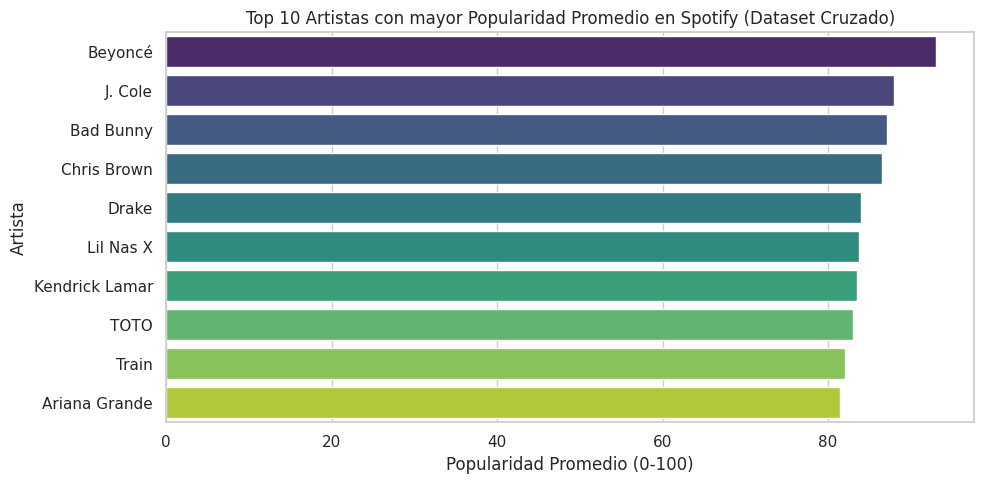

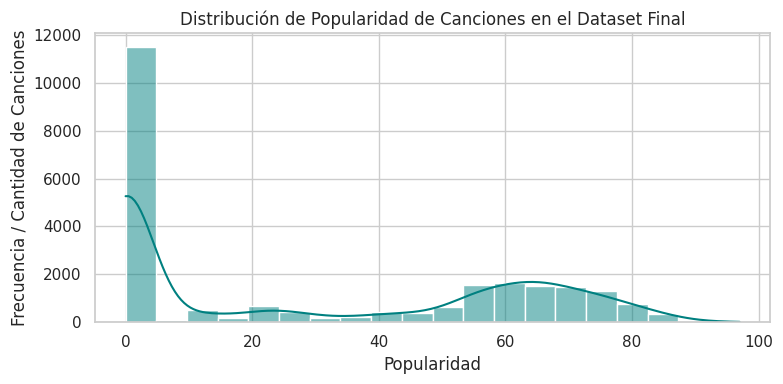

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo gráfico
sns.set_theme(style="whitegrid")

# 1. Conexión a la BD SQLite procesada
conn = sqlite3.connect('data/etl_workshop.db')

# 2. Lectura directa desde la tabla final
query = "SELECT * FROM spotify_grammys_merged"
df_final = pd.read_sql_query(query, conn)

print(f" Total de registros en la BD final: {len(df_final)}\n")
display(df_final.head())

# 3. Gráfico 1: Top 10 artistas (sin advertencia de hue/palette)
plt.figure(figsize=(10, 5))
top_artists = df_final.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=top_artists, x='popularity', y='artists', hue='artists', palette='viridis', legend=False)
plt.title('Top 10 Artistas con mayor Popularidad Promedio en Spotify (Dataset Cruzado)')
plt.xlabel('Popularidad Promedio (0-100)')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

# 4. Gráfico 2: Distribución de la popularidad
plt.figure(figsize=(8, 4))
sns.histplot(df_final['popularity'], kde=True, color='teal', bins=20)
plt.title('Distribución de Popularidad de Canciones en el Dataset Final')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia / Cantidad de Canciones')
plt.tight_layout()
plt.show()

# Cerrar la conexión a la BD
conn.close()